In [551]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [552]:
fuel1 = pd.read_csv("Fuel_Level_Part_1-1.csv")
fuel2 = pd.read_csv("Fuel_Level_Part_2-1.csv")
tanks = pd.read_csv("Tanks-1.csv")
locations = pd.read_csv("Locations-1.csv")
invoices = pd.read_csv("Invoices-1.csv")

# Part 1

In [554]:
for df in [fuel1, fuel2, tanks, locations, invoices]:
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [555]:
if 'timestamp' in fuel1.columns:
    fuel1.rename(columns={'timestamp': 'time_stamp'}, inplace=True)
if 'timestamp' in fuel2.columns:
    fuel2.rename(columns={'timestamp': 'time_stamp'}, inplace=True)

In [556]:
fuel = pd.concat([fuel1, fuel2], ignore_index=True)
fuel['time_stamp'] = pd.to_datetime(fuel['time_stamp'], errors='coerce')
fuel['fuel_level'] = pd.to_numeric(fuel['fuel_level'], errors='coerce')


In [557]:
tanks.rename(columns={'tank_location': 'gas_station_location'}, inplace=True)
invoices.rename(columns={'invoice_gas_station_location': 'gas_station_location'}, inplace=True)

In [558]:
inv_loc = invoices.merge(locations, on='gas_station_location', how='left')
wide_all = inv_loc.merge(tanks, on='gas_station_location', how='left', suffixes=('', '_tank'))

In [559]:
display(fuel.head())
display(wide_all.head())

,tank_id,fuel_level,time_stamp
0,T 12,"27,161.00",2017-01-01 00:10:00
1,T 12,"27,017.00",2017-01-01 00:25:00
2,T 12,"26,934.00",2017-01-01 00:40:00
3,T12,NaN,2017-01-01 00:45:00
4,T 12,"26,786.00",2017-01-01 00:55:00


,invoice_date,invoice_id,gas_station_location,gross_purchase_cost,amount_purchased,fuel_type,gas_station_name,gas_station_address,gas_station_latitude,gas_station_longitude,tank_id,tank_number,tank_type,tank_capacity
0,1/2/2017,"10,000.00",1,"7,570.82","6,609.60",G,EastMount,"386 Upper Gage Ave, Hamilton, ON L8V 4H9, Canada",43.23,-79.84,T 10,1.00,U,"40,000.00"
1,1/2/2017,"10,000.00",1,"7,570.82","6,609.60",G,EastMount,"386 Upper Gage Ave, Hamilton, ON L8V 4H9, Canada",43.23,-79.84,T 11,2.00,U,"40,000.00"
2,1/2/2017,"10,000.00",1,"7,570.82","6,609.60",G,EastMount,"386 Upper Gage Ave, Hamilton, ON L8V 4H9, Canada",43.23,-79.84,T 12,3.00,D,"40,000.00"
3,1/2/2017,"10,000.00",1,"7,570.82","6,609.60",G,EastMount,"386 Upper Gage Ave, Hamilton, ON L8V 4H9, Canada",43.23,-79.84,T 13,4.00,P,"40,000.00"
4,1/2/2017,"10,000.00",1,"7,570.82","6,609.60",G,EastMount,"386 Upper Gage Ave, Hamilton, ON L8V 4H9, Canada",43.23,-79.84,T 14,5.00,U,"40,000.00"


In [560]:
fuel['time_stamp'] = pd.to_datetime(fuel['time_stamp'], errors='coerce')
fuel['fuel_level'] = pd.to_numeric(fuel['fuel_level'], errors='coerce')
fuel = fuel.dropna(subset=['tank_id','time_stamp','fuel_level']).sort_values(['tank_id','time_stamp'])

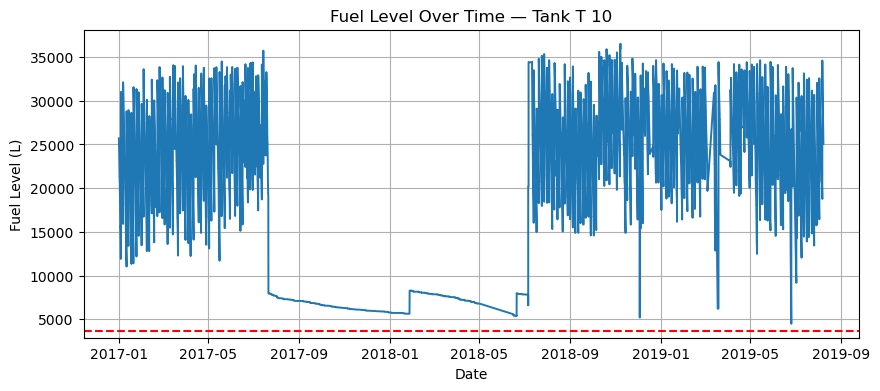

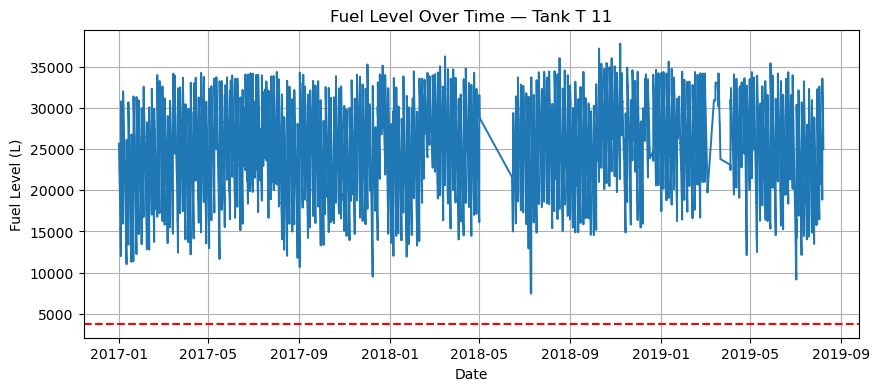

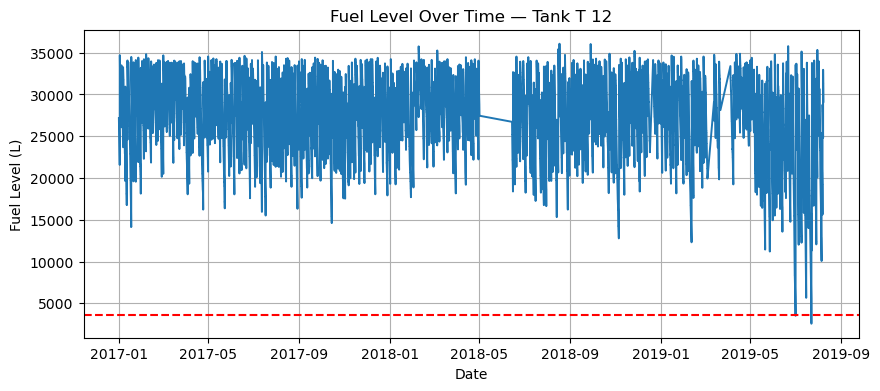

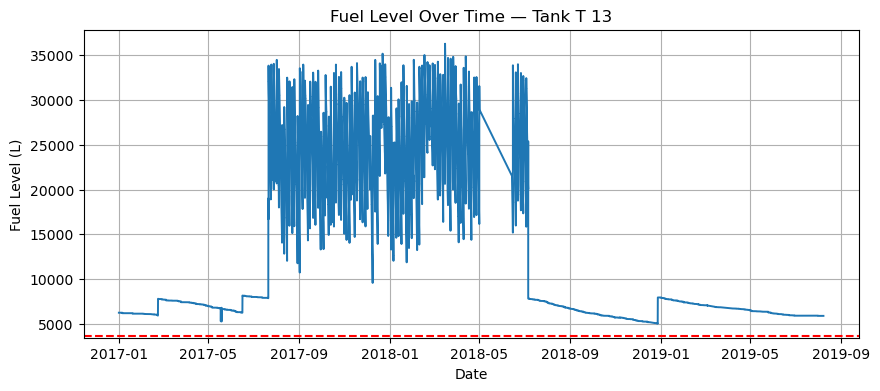

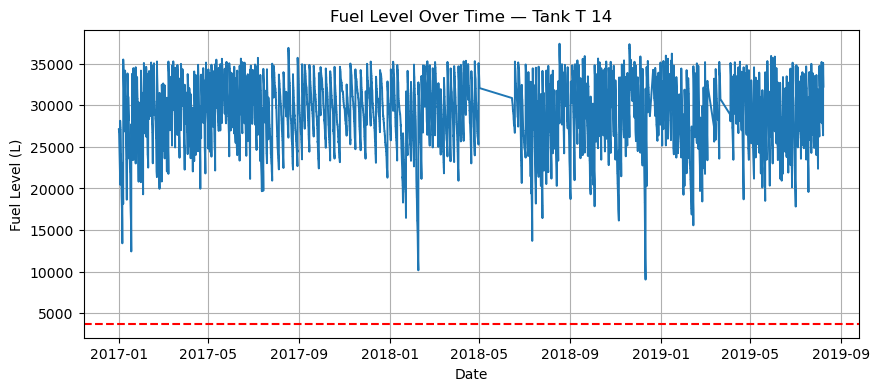

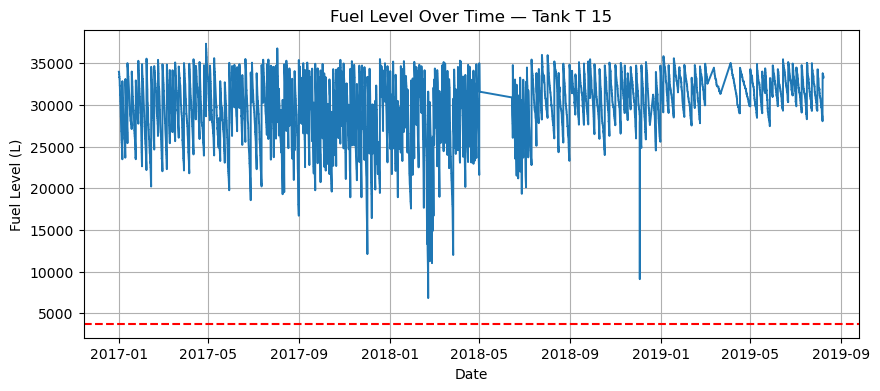

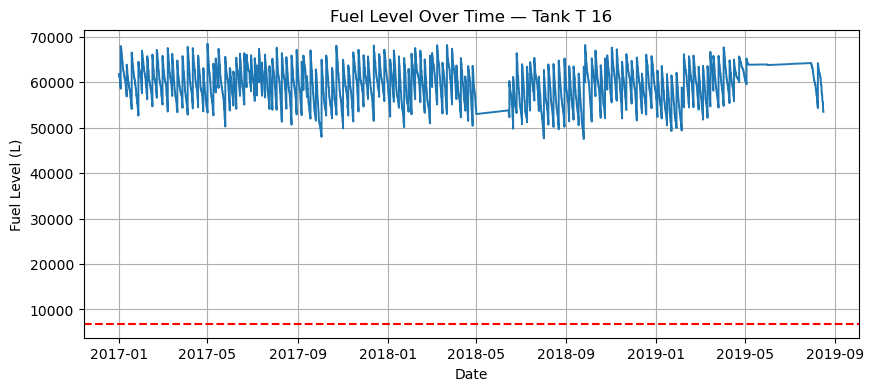

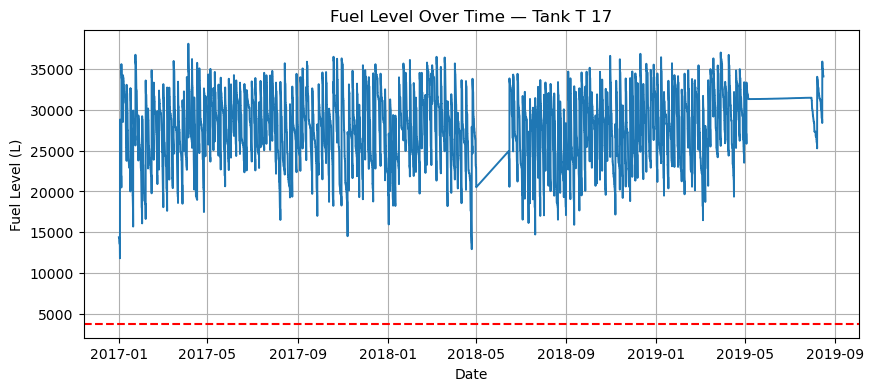

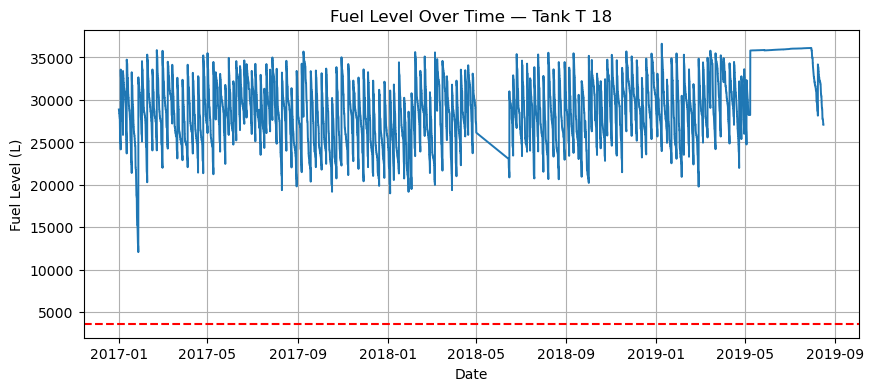

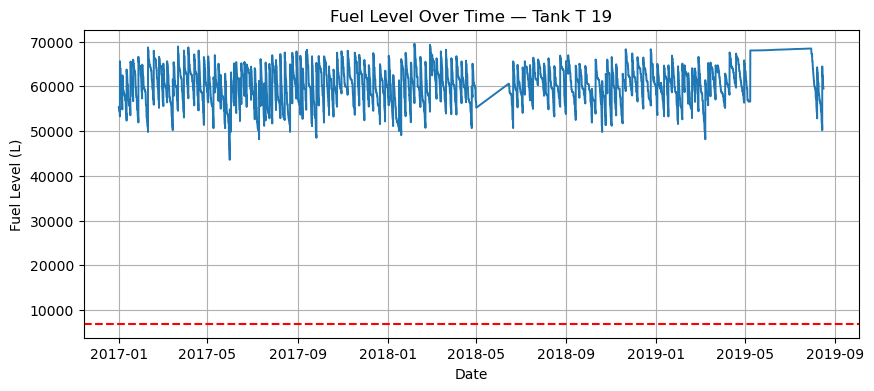

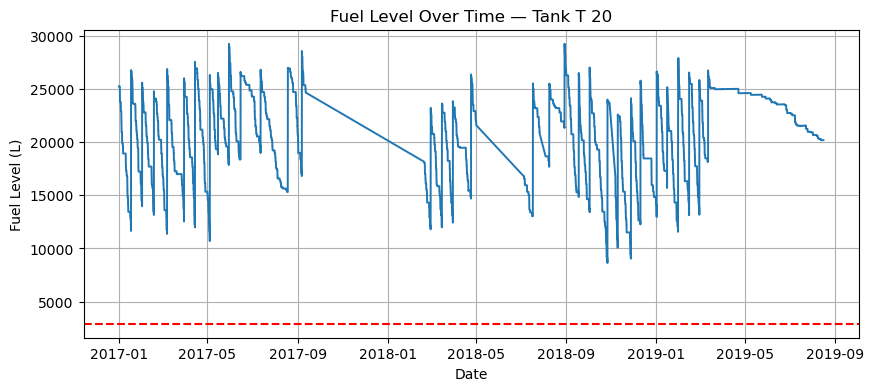

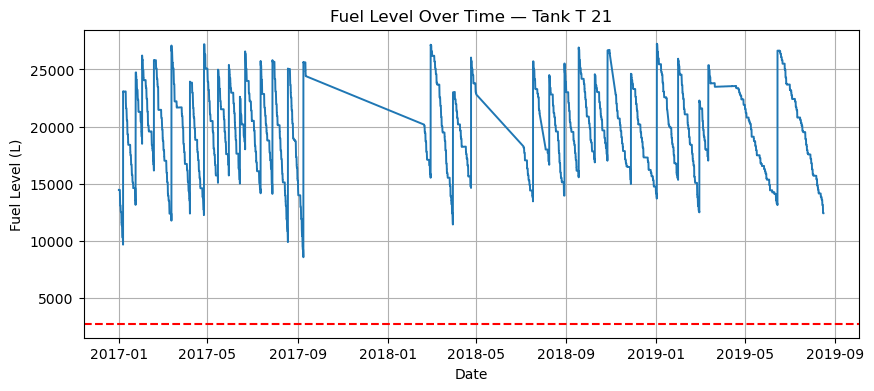

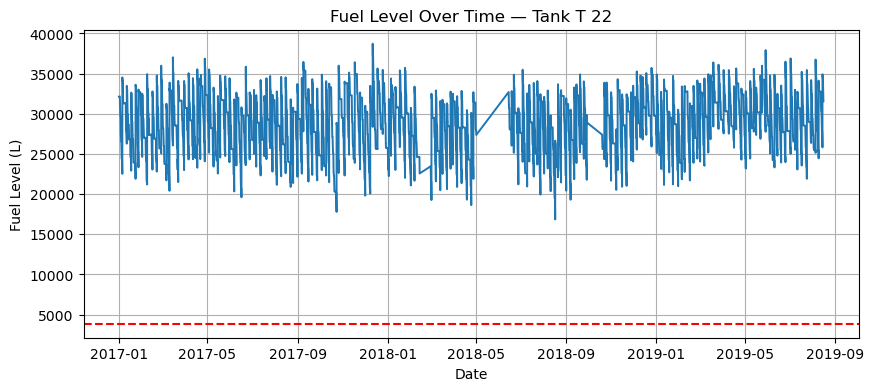

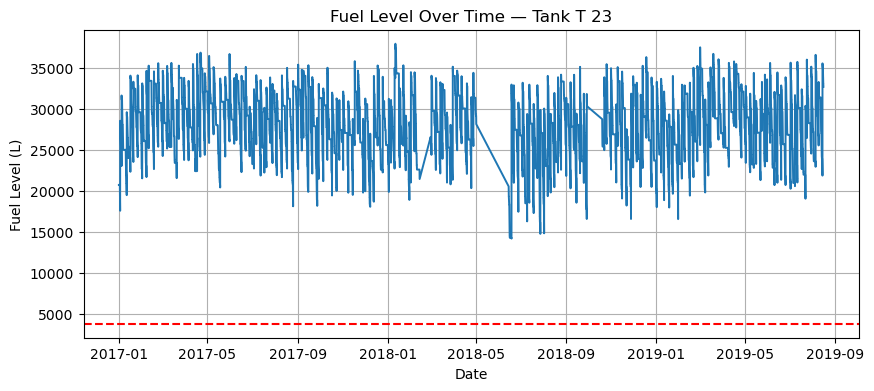

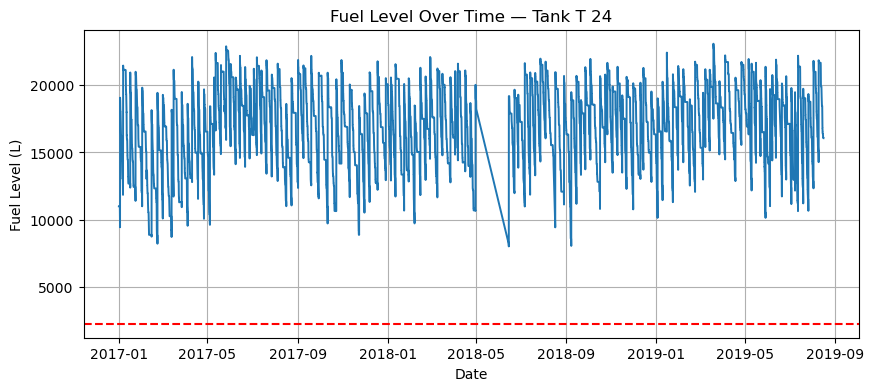

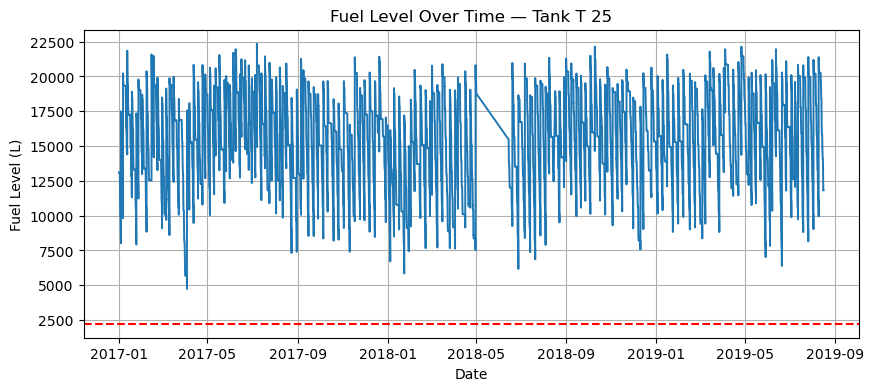

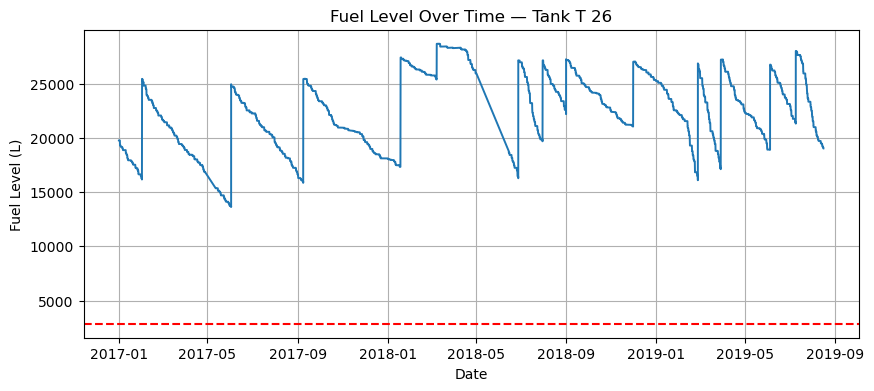

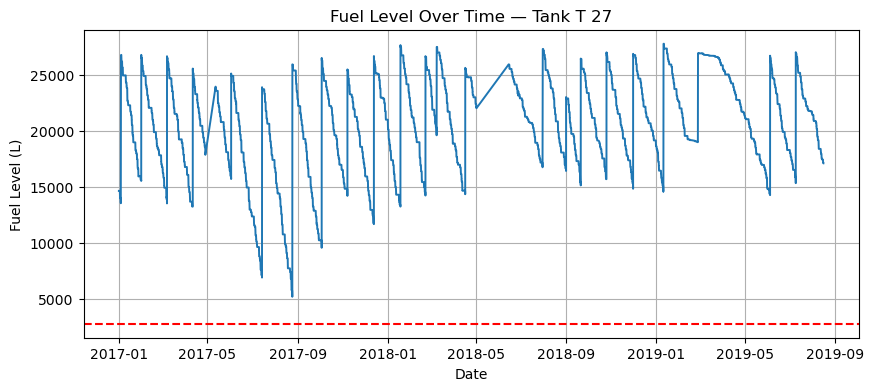

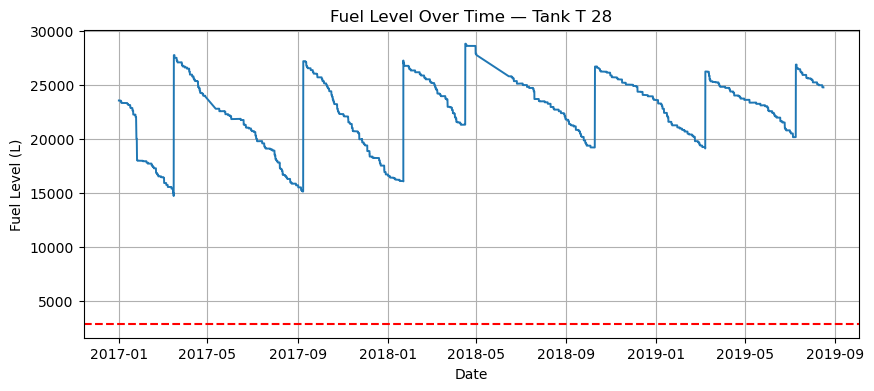

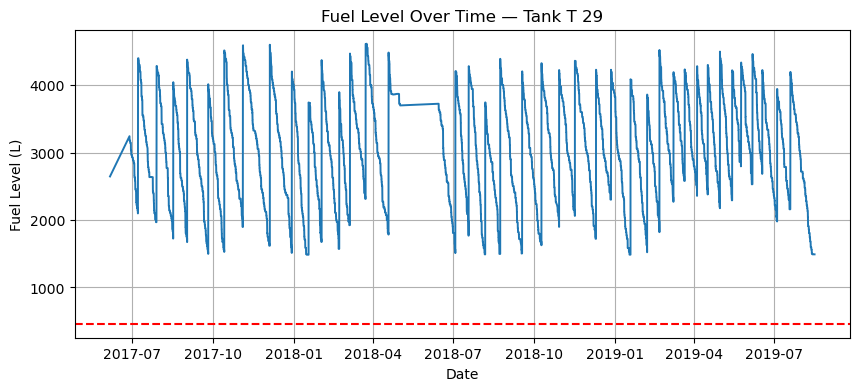

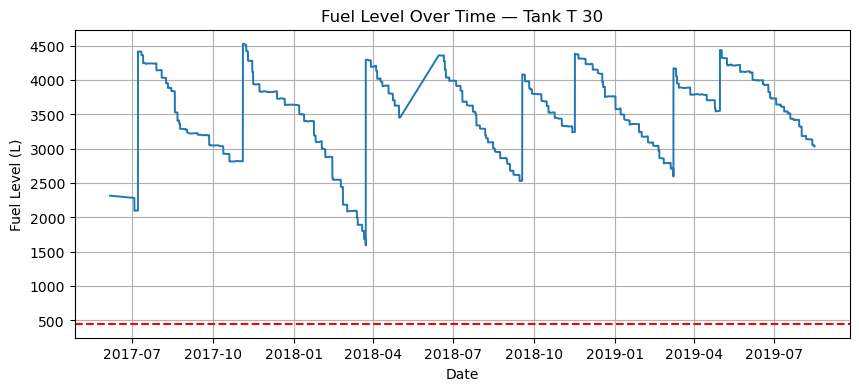

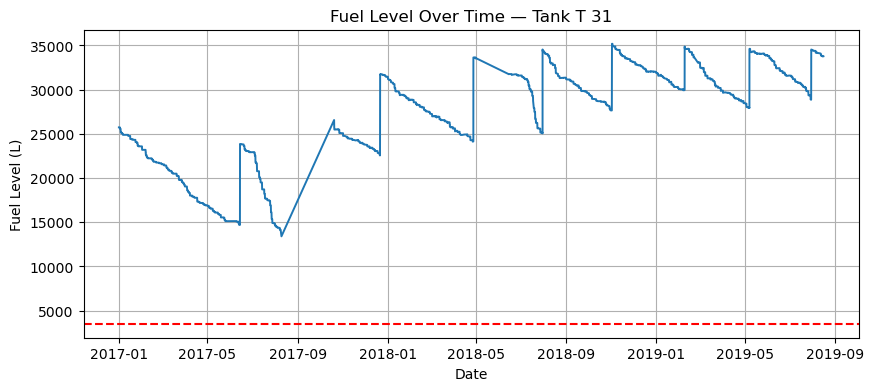

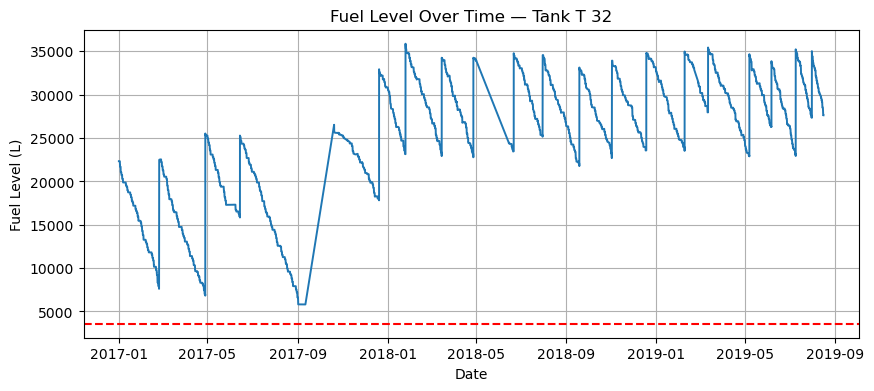

In [561]:
for tank_id, df in fuel.groupby('tank_id', sort=False):
    if len(df) < 2: 
        continue
        
    plt.figure(figsize=(10,4))
    plt.plot(df['time_stamp'], df['fuel_level'], linewidth=1.4)
    
    threshold = 0.10 * df['fuel_level'].max()
    plt.axhline(y=threshold, color='red', linestyle='--', label='10% Threshold')
    
    plt.title(f"Fuel Level Over Time — Tank {tank_id}")
    plt.xlabel("Date")
    plt.ylabel("Fuel Level (L)")
    plt.grid(True)
    plt.show()
    

In [562]:
fuel['fuel_level_pct'] = fuel['fuel_level'] / fuel.groupby('tank_id')['fuel_level'].transform('max')
fuel['date'] = fuel['time_stamp'].dt.date
tank_summary = (
    fuel.groupby('tank_id')
        .agg(
            avg_level=('fuel_level_pct', 'mean'),
            min_level=('fuel_level_pct', 'min'),
            std_level=('fuel_level_pct', 'std'),
            days=('date', 'nunique')
        )
        .reset_index()
)

In [563]:
tank_summary['status'] = np.where(
    tank_summary['min_level'] < 0.10,
    'At Risk of Stockout',
    'Effective Management'
)

In [564]:
tanks.columns = tanks.columns.str.strip().str.lower().str.replace(' ', '_')
tank_summary = tank_summary.merge(
    tanks[['tank_id', 'gas_station_location', 'tank_capacity', 'tank_type']],
    on='tank_id', how='left'
)

station_summary = (
    tank_summary.groupby('gas_station_location')
    .agg(
        avg_min_level=('min_level', 'mean'),
        avg_std=('std_level', 'mean'),
        tanks=('tank_id', 'count')
    )
    .reset_index()
)

station_summary['status'] = np.where(
    station_summary['avg_min_level'] < 0.10,
    'At Risk of Stockout',
    'Effective Management'
)

In [565]:
display(tank_summary.head(23))
display(station_summary.sort_values('avg_min_level'))

,tank_id,avg_level,min_level,std_level,days,status,gas_station_location,tank_capacity,tank_type
0,T 10,0.52,0.12,0.26,882,Effective Management,1,40000,U
1,T 11,0.66,0.20,0.13,882,Effective Management,1,40000,U
2,T 12,0.75,0.07,0.12,882,At Risk of Stockout,1,40000,D
3,T 13,0.36,0.14,0.25,882,Effective Management,1,40000,P
4,T 14,0.77,0.24,0.10,881,Effective Management,1,40000,U
5,T 15,0.80,0.18,0.10,882,Effective Management,1,40000,D
6,T 16,0.87,0.69,0.06,914,Effective Management,2,70000,U
7,T 17,0.73,0.31,0.11,914,Effective Management,2,40000,D
8,T 18,0.80,0.33,0.11,914,Effective Management,2,40000,U
9,T 19,0.88,0.63,0.06,914,Effective Management,2,70000,D


,gas_station_location,avg_min_level,avg_std,tanks,status
0,1,0.16,0.16,6,Effective Management
7,8,0.27,0.18,2,Effective Management
4,5,0.28,0.14,2,Effective Management
2,3,0.30,0.14,2,Effective Management
6,7,0.34,0.15,2,Effective Management
5,6,0.39,0.13,3,Effective Management
3,4,0.40,0.10,2,Effective Management
1,2,0.49,0.08,4,Effective Management


#### Overall, tanks that keep their levels consistently above the red line demonstrate effective inventory management.
#### Stations such as T 12 has the blue line dropping below the red dashed line.
#### This indicates that the fuel level gets dangerously low before refilling.

In [567]:
invoices['invoice_date'] = pd.to_datetime(invoices['invoice_date'], errors='coerce')
invoices['gross_purchase_cost'] = pd.to_numeric(invoices['gross_purchase_cost'], errors='coerce')
invoices['amount_purchased'] = pd.to_numeric(invoices['amount_purchased'], errors='coerce')

In [568]:
def discount_per_liter(qty):
    if pd.isna(qty): return 0
    if qty < 15000: return 0.00
    elif qty < 25000: return 0.02
    elif qty < 40000: return 0.03
    else: return 0.04

In [569]:
invoices['discount_per_liter'] = invoices['amount_purchased'].apply(discount_per_liter)
invoices['discount_total'] = invoices['discount_per_liter'] * invoices['amount_purchased']

loc_col = 'invoice_gas_station_location' if 'invoice_gas_station_location' in invoices.columns else 'gas_station_location'
invoices_subset = invoices[invoices[loc_col].between(1, 8, inclusive='both')]

In [570]:
savings_by_station = (
    invoices_subset.groupby(loc_col)['discount_total']
    .sum()
    .reset_index()
    .rename(columns={'discount_total':'total_discount_cad'})
    .sort_values('total_discount_cad', ascending=False)
)

print("Estimated savings from quantity discounts (Stations 1–8):")
display(savings_by_station)

Estimated savings from quantity discounts (Stations 1–8):


,gas_station_location,total_discount_cad
0,1,"190,587.38"
1,2,"10,296.32"
2,3,"1,955.05"
5,6,"1,461.90"
7,8,"1,335.40"
3,4,343.37
4,5,0.00
6,7,0.00


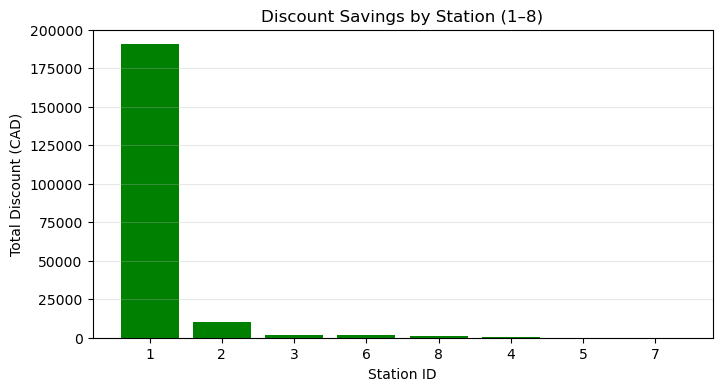

In [571]:
plt.figure(figsize=(8,4))
plt.bar(savings_by_station[loc_col].astype(str), savings_by_station['total_discount_cad'], color='green')
plt.xlabel("Station ID")
plt.ylabel("Total Discount (CAD)")
plt.title("Discount Savings by Station (1–8)")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Part 2


In [573]:
capacity_summary = (
    wide_all.groupby(['gas_station_location', 'fuel_type'])['tank_capacity']
    .sum()
    .reset_index()
    .rename(columns={'tank_capacity': 'total_capacity'})
)


In [574]:
def discount_rate(qty):
    if qty > 40000:
        return 0.04
    elif qty > 25000:
        return 0.03
    elif qty > 15000:
        return 0.02
    else:
        return 0.00

capacity_summary['max_discount'] = capacity_summary['total_capacity'].apply(discount_rate)

In [575]:
invoices = wide_all.copy()
invoices['invoice_date'] = pd.to_datetime(invoices['invoice_date'], errors='coerce')

consumption_summary = (
    invoices.groupby(['gas_station_location', 'fuel_type'])
    .agg(
        total_purchased=('amount_purchased', 'sum'),
        first_date=('invoice_date', 'min'),
        last_date=('invoice_date', 'max')
    )
    .reset_index()
)


In [576]:
consumption_summary['days'] = (consumption_summary['last_date'] - consumption_summary['first_date']).dt.days
consumption_summary['avg_daily_consumption'] = consumption_summary['total_purchased'] / consumption_summary['days']

In [577]:
consumption_summary['threshold_7day'] = consumption_summary['avg_daily_consumption'] * 7
summary = capacity_summary.merge(consumption_summary, on=['gas_station_location', 'fuel_type'], how='left')


In [578]:
summary['potential_savings'] = summary['total_purchased'] * summary['max_discount']

In [579]:
consumption_summary['days'] = (consumption_summary['last_date'] - consumption_summary['first_date']).dt.days
consumption_summary['avg_daily_consumption'] = consumption_summary['total_purchased'] / consumption_summary['days']

In [580]:
consumption_summary['threshold_7day'] = consumption_summary['avg_daily_consumption'] * 7
summary = capacity_summary.merge(consumption_summary, on=['gas_station_location', 'fuel_type'], how='left')
summary['potential_savings'] = summary['total_purchased'] * summary['max_discount']

In [581]:
def recommendation(row):
    if row['max_discount'] == 0:
        return "Increase order size to at least 15,000L to qualify for 2¢/L discount"
    elif row['max_discount'] == 0.02:
        return "Increase orders toward 25,000L to qualify for 3¢/L discount"
    elif row['max_discount'] == 0.03:
        return "Increase orders toward 40,000L to qualify for 4¢/L discount"
    else:
        return "Maintain current strategy; already at maximum discount"

summary['recommendation'] = summary.apply(recommendation, axis=1)

In [582]:
order_summary = (
    wide_all.groupby(['gas_station_location','fuel_type'])['amount_purchased']
    .mean()
    .reset_index()
    .rename(columns={'amount_purchased':'avg_order_size'})
)

In [583]:
capacity_summary = (
    wide_all.groupby(['gas_station_location','fuel_type'])['tank_capacity']
    .sum()
    .reset_index()
    .rename(columns={'tank_capacity':'total_capacity'})
)

In [584]:
compare = order_summary.merge(capacity_summary, on=['gas_station_location','fuel_type'])
compare['current_discount'] = compare['avg_order_size'].apply(discount_rate)
compare['potential_discount'] = compare['total_capacity'].apply(discount_rate)

In [585]:
def improved_rec(row):
    if row['current_discount'] < row['potential_discount']:
        return f"Increase order size from {row['avg_order_size']:.0f}L to {row['total_capacity']:.0f}L to reach higher discount tier."
    else:
        return "Maintain current strategy; already optimized."

compare['recommendation'] = compare.apply(improved_rec, axis=1)

In [586]:
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
display(compare[['gas_station_location','fuel_type','avg_order_size',
                 'total_capacity','current_discount','potential_discount',
                 'recommendation']].sort_values('potential_discount', ascending=False))


,gas_station_location,fuel_type,avg_order_size,total_capacity,current_discount,potential_discount,recommendation
0,1,D,"8,134.32","143,760,000.00",0.00,0.04,Increase order size from 8134L to 143760000L t...
1,1,G,"14,260.12","182,880,000.00",0.00,0.04,Increase order size from 14260L to 182880000L ...
2,2,D,"9,973.77","76,340,000.00",0.00,0.04,Increase order size from 9974L to 76340000L to...
3,2,G,"9,903.56","62,700,000.00",0.00,0.04,Increase order size from 9904L to 62700000L to...
4,3,D,"10,532.08","2,460,000.00",0.00,0.04,Increase order size from 10532L to 2460000L to...
5,3,G,"10,859.45","2,340,000.00",0.00,0.04,Increase order size from 10859L to 2340000L to...
6,4,D,"8,872.11","14,720,000.00",0.00,0.04,Increase order size from 8872L to 14720000L to...
7,4,G,"9,178.01","13,760,000.00",0.00,0.04,Increase order size from 9178L to 13760000L to...
8,5,D,"6,493.87","6,250,000.00",0.00,0.04,Increase order size from 6494L to 6250000L to ...
9,5,G,"8,688.47","7,750,000.00",0.00,0.04,Increase order size from 8688L to 7750000L to ...


## Key findings:
#### 1. Across all stations, the current discount is 0.00 CAD/L, indicating that most locations currently order below the minimum 15,000 L threshold required to earn a volume discount.
#### 2. The potential discount column shows that every station could reach the highest tier (0.04 CAD/L) if they were able to fill up to their total tank capacity.
#### 3. Stations 1 (G) and 1 (D) exhibit the largest total capacities and therefore the greatest opportunity for savings. For example, if Station 1 (G) increased its order from 14 k L to 182 k L, it could save an additional $0.04 per liter purchased. And Smaller stations like Locations 10 and 12 show smaller tank capacities and lower average daily usage, meaning they cannot achieve the same economies of scale even if they fill to capacity.
## Recommendations: 
#### 1. Focus on high-capacity stations like Locations 1–3 for strategic purchasing, because they are capable of reaching higher discount tiers quickly.
#### 2. Schedule fewer deliveries. We can have larger refills instead of frequent small ones, which would reduce our costs.

# Part 3

In [589]:
d = wide_all.copy()
d["_dt"] = pd.to_datetime(d["invoice_date"], errors="coerce")
d["amount_purchased"] = pd.to_numeric(d["amount_purchased"], errors="coerce")
d["gross_purchase_cost"] = pd.to_numeric(d["gross_purchase_cost"], errors="coerce")
d = d[(d["amount_purchased"] > 0) & (d["gross_purchase_cost"] > 0) & d["_dt"].notna()].copy()

In [590]:
d["price_per_liter"] = d["gross_purchase_cost"] / d["amount_purchased"]
weekday_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
d["weekday_num"] = d["_dt"].dt.weekday
d["weekday"] = d["weekday_num"].map(dict(enumerate(weekday_labels)))

In [591]:
ppl = d["price_per_liter"]
q1, q3 = ppl.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
d_f = d[(ppl >= max(lo, 0)) & (ppl <= hi)].copy()

In [592]:
def IQR(s):
    return s.quantile(0.75) - s.quantile(0.25)

In [593]:
summary_raw = (
    d.groupby("weekday")["price_per_liter"]
     .agg(n="count", mean="mean", median="median", std="std", iqr=IQR, min="min", max="max")
     .reindex(weekday_labels)
).round(6)

summary_filt = (
    d_f.groupby("weekday")["price_per_liter"]
       .agg(n="count", mean="mean", median="median", std="std", iqr=IQR, min="min", max="max")
       .reindex(weekday_labels)
).round(6)

In [594]:
print("Price per Liter by Weekday")
print(summary_raw.to_string(index=True))

print("Price per Liter by Weekday (Filtered)")
print(summary_filt.to_string(index=True))

Price per Liter by Weekday
               n  mean  median  std  iqr  min  max
weekday                                           
Mon     2,451.00  1.19    1.06 0.31 0.16 0.92 3.23
Tue     2,340.00  1.25    1.07 0.36 0.20 0.92 2.72
Wed     2,588.00  1.20    1.06 0.34 0.17 0.91 3.24
Thu     1,286.00  1.19    1.06 0.30 0.18 0.89 2.81
Fri     3,673.00  1.22    1.07 0.34 0.22 0.88 2.86
Sat        74.00  1.07    1.06 0.11 0.05 0.91 1.35
Sun          NaN   NaN     NaN  NaN  NaN  NaN  NaN
Price per Liter by Weekday (Filtered)
               n  mean  median  std  iqr  min  max
weekday                                           
Mon     2,207.00  1.10    1.06 0.13 0.15 0.92 1.48
Tue     1,961.00  1.11    1.06 0.12 0.15 0.92 1.53
Wed     2,344.00  1.11    1.06 0.13 0.15 0.91 1.52
Thu     1,158.00  1.10    1.06 0.13 0.15 0.89 1.49
Fri     3,231.00  1.11    1.06 0.13 0.15 0.88 1.54
Sat        74.00  1.07    1.06 0.11 0.05 0.91 1.35
Sun          NaN   NaN     NaN  NaN  NaN  NaN  NaN


#### After IQR, we can use the filtered dataframe to better understand the data, because there are some extreme numbers that could influence the data.

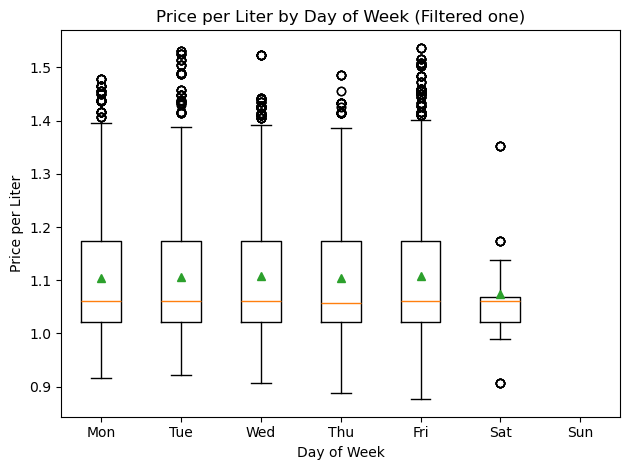

In [596]:
data_by_day_filt = [d_f.loc[d_f["weekday"]==w, "price_per_liter"].values for w in weekday_labels]
plt.boxplot(data_by_day_filt, tick_labels=weekday_labels, showmeans=True)
plt.title("Price per Liter by Day of Week (Filtered one)")
plt.xlabel("Day of Week")
plt.ylabel("Price per Liter")
plt.tight_layout()
plt.show()

In [597]:
low_median_day  = summary_filt["median"].idxmin()
low_mean_day    = summary_filt["mean"].idxmin()
print(f"Lowest median : {low_median_day}")
print(f"Lowest mean   : {low_mean_day}")

Lowest median : Thu
Lowest mean   : Sat


#### We have median and mean to identify the lowest rate, as we are focusing on the cost and revenue, mean can be the better answer. However, Saturday's sample size is much smaller than the other days', its data persuasiveness is insufficient. The sceond lowest rate is 
#### Thursday: 1.103587

In [599]:
d_iqr = d[(ppl >= max(lo, 0)) & (ppl <= hi)].copy()
thu_mean_iqr = 1.103587

In [600]:
def compute_savings(df, target_ppl):
    per_txn_saving = (df["price_per_liter"] - target_ppl).clip(lower=0) * df["amount_purchased"]
    total_saving = per_txn_saving.sum()
    total_cost   = (df["price_per_liter"] * df["amount_purchased"]).sum()
    pct_saving   = total_saving / total_cost if total_cost > 0 else np.nan
    return total_saving, total_cost, pct_saving, per_txn_saving

In [601]:
total_saving_iqr, total_cost_iqr, pct_saving_iqr, per_txn_saving_iqr = compute_savings(d, thu_mean_iqr)

In [602]:
print("Total saving vs Thu mean (IQR) :", round(total_saving_iqr, 2), f"({pct_saving_iqr:.2%})")

Total saving vs Thu mean (IQR) : 12268787.19 (7.97%)


#### Additional savings are: 12268805.3 if purchases were consistently made on Thursday's price.

# Part 4

In [605]:
NEW_TANK_CAPACITY_L = 30000      
TANK_COST_CAD       = 100000     
DISCOUNT_RATE       = 0.02      
YEARS               = 5

In [606]:
tanks = tanks.copy()
fuel  = fuel.copy()

In [607]:
fuel['time_stamp'] = pd.to_datetime(fuel['time_stamp'], errors='coerce')
fuel['fuel_level'] = pd.to_numeric(fuel['fuel_level'], errors='coerce')
fuel = fuel.dropna(subset=['tank_id','time_stamp','fuel_level']).sort_values(['tank_id','time_stamp'])

In [608]:
fuel['diff'] = fuel.groupby('tank_id')['fuel_level'].diff()
fuel['usage_liters'] = (-fuel['diff']).clip(lower=0)   
fuel['date'] = fuel['time_stamp'].dt.date

In [609]:
avg_daily = (fuel.groupby(['tank_id','date'])['usage_liters'].sum()
                .groupby('tank_id').mean()
                .reset_index(name='avg_daily_liters'))

In [610]:
avg_daily = avg_daily.merge(
    tanks[['tank_id','gas_station_location','tank_type','tank_capacity']].drop_duplicates(),
    on='tank_id', how='left'
)

In [611]:
site = (avg_daily.groupby(['gas_station_location','tank_type'], dropna=False)
                 .agg(avg_daily_liters=('avg_daily_liters','sum'),
                      tank_capacity=('tank_capacity','sum'))
                 .reset_index())


In [612]:
site['threshold_7d']   = site['avg_daily_liters'] * 7
site['order_current']  = (site['tank_capacity'] - site['threshold_7d']).clip(lower=0)
site['capacity_exp']   = site['tank_capacity'] + NEW_TANK_CAPACITY_L
site['order_expanded'] = (site['capacity_exp'] - site['threshold_7d']).clip(lower=0)

In [613]:
def discount_per_liter(q):
    if q < 15000:  return 0.00
    if q < 25000:  return 0.02
    if q < 40000:  return 0.03
    return 0.04

site['disc_current']  = site['order_current'].apply(discount_per_liter)
site['disc_expanded'] = site['order_expanded'].apply(discount_per_liter)


In [614]:

site['annual_liters']        = site['avg_daily_liters'] * 365
site['delta_disc']           = (site['disc_expanded'] - site['disc_current']).clip(lower=0)
site['annual_extra_savings'] = site['delta_disc'] * site['annual_liters']

npv_factor = sum(1 / ((1 + DISCOUNT_RATE) ** t) for t in range(1, YEARS + 1))
site['npv_extra_savings'] = site['annual_extra_savings'] * npv_factor

In [615]:

site['is_worth_it'] = site['npv_extra_savings'] > TANK_COST_CAD
result = (site.rename(columns={'gas_station_location':'location'})[
            ['location','tank_type',
             'tank_capacity','threshold_7d',
             'order_current','disc_current',
             'capacity_exp','order_expanded','disc_expanded',
             'avg_daily_liters','annual_liters',
             'annual_extra_savings','npv_extra_savings','is_worth_it']]
          .sort_values('npv_extra_savings', ascending=False))

In [616]:
print("Feasibility results:")
display(result)

print("Positive ROI (NPV > cost):")
display(result[result['is_worth_it']])

Feasibility results:


,location,tank_type,tank_capacity,threshold_7d,order_current,disc_current,capacity_exp,order_expanded,disc_expanded,avg_daily_liters,annual_liters,annual_extra_savings,npv_extra_savings,is_worth_it
0,1,D,80000,"50,355.31","29,644.69",0.03,110000,"59,644.69",0.04,"7,193.62","2,625,669.71","26,256.70","123,759.88",True
10,5,U,25000,"10,860.40","14,139.60",0.00,55000,"44,139.60",0.04,"1,551.49","566,292.50","22,651.70","106,767.87",True
9,5,D,25000,"7,480.52","17,519.48",0.02,55000,"47,519.48",0.04,"1,068.65","390,055.87","7,801.12","36,770.25",False
7,4,D,40000,"14,738.90","25,261.10",0.03,70000,"55,261.10",0.04,"2,105.56","768,528.42","7,685.28","36,224.28",False
8,4,U,40000,"13,301.45","26,698.55",0.03,70000,"56,698.55",0.04,"1,900.21","693,575.40","6,935.75","32,691.40",False
1,1,P,40000,"11,394.78","28,605.22",0.03,70000,"58,605.22",0.04,"1,627.83","594,156.27","5,941.56","28,005.32",False
6,3,U,30000,"3,860.07","26,139.93",0.03,60000,"56,139.93",0.04,551.44,"201,275.13","2,012.75","9,487.02",False
5,3,D,30000,"3,344.87","26,655.13",0.03,60000,"56,655.13",0.04,477.84,"174,411.03","1,744.11","8,220.79",False
14,7,U,5000,895.88,"4,104.12",0.00,35000,"34,104.12",0.03,127.98,"46,713.56","1,401.41","6,605.47",False
16,8,U,40000,"1,892.03","38,107.97",0.03,70000,"68,107.97",0.04,270.29,"98,655.90",986.56,"4,650.11",False


Positive ROI (NPV > cost):


,location,tank_type,tank_capacity,threshold_7d,order_current,disc_current,capacity_exp,order_expanded,disc_expanded,avg_daily_liters,annual_liters,annual_extra_savings,npv_extra_savings,is_worth_it
0,1,D,80000,"50,355.31","29,644.69",0.03,110000,"59,644.69",0.04,"7,193.62","2,625,669.71","26,256.70","123,759.88",True
10,5,U,25000,"10,860.40","14,139.60",0.00,55000,"44,139.60",0.04,"1,551.49","566,292.50","22,651.70","106,767.87",True


## Results and Conclusion:
#### For Station 1, allows the station to place larger fuel orders — roughly 59,000L instead of 30,000L each time. That moves it from a 3% discount tier up to 4%, and because this station sells a lot of diesel (about 7,200 L per day), the savings add up quickly. Over five years, the total savings (net present value about 124k) are greater than the 100k cost, so the investment is worth it.
#### Station 5 also benefits because its new order size grows enough to reach the 4% discount tier from 0%. Even though its consumption is smaller (about 1,550 L/day), the discount increase still has a good positive NPV (about $107k).
#### Since only Station 1 (Diesel) and Station 5 (Regular) show positive ROI, meaning that adding an extra tank would benefit these two stations frome expansion within five years. For other stations, adding capacity is not cost-effective comparing to Station 1 and 5. Management should prioritize these two high-volume stations if there is funding for new tanks.